# Laboratorio Dirigido N.° 05
## Motor de decisión ante riesgo cambiario

**Curso:** Analítica Empresarial Integrada  
**Semana:** 5  
**Caso:** una empresa importadora peruana debe pagar **USD 100 000 dentro de 60 días**.  
**Fuente:** API pública de Series Estadísticas del Banco Central de Reserva del Perú.

### Pregunta orientadora
¿Cómo tomar una decisión defendible cuando no conocemos con certeza el tipo de cambio futuro?

> Este notebook se desarrolla íntegramente durante la clase con acompañamiento docente. No constituye una tarea, exposición ni entregable.

**Corte de la revisión: 20/09/2026.** Las interpretaciones numéricas Markdown describen las salidas guardadas. Si se modifica el corte o se vuelve a consultar una fuente revisada, deben actualizarse también estos textos. Se conserva el método académico original y se explicitan sus límites.

## Ruta de trabajo

1. Conexión y parámetros del caso.  
2. Descarga y trazabilidad de las series del BCRP.  
3. Limpieza y control de calidad.  
4. Selección explícita de la serie de venta.  
5. Retornos y volatilidad.  
6. Simulación Monte Carlo.  
7. Comparación entre comprar hoy y esperar.  
8. Motor transparente de decisión.  
9. Sensibilidad y reto en clase.

## BLOQUE 1 — Conexión, trazabilidad y calidad

### Celda 1 — Entorno de trabajo

### Propósito y justificación

Esta celda importa las librerías para consultar la API, limpiar datos, calcular retornos y construir las tablas y gráficas. También configura una presentación legible de las tablas. Se ejecuta primero porque todas las celdas siguientes dependen de estos objetos.

In [1]:
# Librerías disponibles por defecto en Google Colab.
import sys
import platform
from datetime import date, timedelta

import numpy as np
import pandas as pd
import requests
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 150)

print("Python:", sys.version.split()[0])
print("Plataforma:", platform.platform())
print("Entorno listo.")
import matplotlib.pyplot as plt
import hashlib, json
pd.set_option("display.max_colwidth", None)

Python: 3.12.10
Plataforma: Windows-11-10.0.26200-SP0
Entorno listo.


### Interpretación de los resultados

El entorno ejecutó las importaciones correctamente. Las versiones mostradas documentan el entorno de esta revisión.

### Celda 2 — Parámetros visibles y editables

### Propósito y justificación

Esta celda concentra los supuestos editables: monto de la obligación, horizonte, número de escenarios, ventana histórica, semilla y tolerancias del motor. Separarlos del cálculo permite modificar un supuesto y observar su efecto sin reescribir la lógica.

In [2]:
# Parámetros empresariales
MONTO_USD = 100_000
HORIZONTE_CALENDARIO = 60
ESCENARIOS = 20_000
VENTANA_BASE = 252
SEMILLA = 2026

# Umbrales académicos del motor de decisión
TOLERANCIA_PROB_SOBRECOSTO = 0.40
TOLERANCIA_SOBRECOSTO_P95 = 0.02  # 2 % respecto de comprar hoy

# Series diarias del BCRP: compra y venta interbancaria (S/ por US$)
SERIES = ["PD04637PD", "PD04638PD"]
FECHA_FIN = date(2026, 9, 20)  # Corte fijo de esta revisión; modificar para actualizar
FECHA_INICIO = FECHA_FIN - timedelta(days=5 * 365)

print(f"Obligación: USD {MONTO_USD:,.0f}")
print(f"Horizonte: {HORIZONTE_CALENDARIO} días calendario")
print(f"Escenarios: {ESCENARIOS:,}")
print(f"Periodo solicitado: {FECHA_INICIO} a {FECHA_FIN}")

Obligación: USD 100,000
Horizonte: 60 días calendario
Escenarios: 20,000
Periodo solicitado: 2021-09-21 a 2026-09-20


### Interpretación de los resultados

Se comparan USD 100 000 a 60 días calendario, con 20 000 escenarios y semilla 2026. El corte se fija al 20/09/2026. La semilla reproduce el muestreo con los mismos datos y entorno; no congela futuras revisiones de la API.

### Celda 3 — Consulta a la API del BCRP

Se solicitan las dos series por su código oficial. La respuesta se valida antes de continuar.

### Propósito y justificación

Esta celda consulta directamente las series oficiales del BCRP para tipo de cambio interbancario de compra y venta. Valida el estado HTTP, la estructura JSON y la presencia de series y periodos antes de continuar, y deja visible la URL para trazabilidad.

In [3]:
BASE_API = "https://estadisticas.bcrp.gob.pe/estadisticas/series/api"
codigos = "-".join(SERIES)
URL = f"{BASE_API}/{codigos}/json/{FECHA_INICIO.isoformat()}/{FECHA_FIN.isoformat()}/esp"

respuesta = requests.get(
    URL,
    timeout=60,
    headers={"User-Agent": "Mozilla/5.0 (compatible; TECSUP-lab/1.0)"},
)
print("Estado HTTP:", respuesta.status_code)
respuesta.raise_for_status()
datos_json = respuesta.json()
if "config" not in datos_json or "periods" not in datos_json:
    raise ValueError("La respuesta del BCRP no contiene 'config' y 'periods'.")
if not datos_json["config"].get("series") or not datos_json["periods"]:
    raise ValueError("El BCRP no devolvió series o periodos utilizables.")
print("Series recibidas:", len(datos_json["config"]["series"]))
print("Periodos recibidos:", len(datos_json["periods"]))
print("URL consultada:", URL)
print("SHA-256 de la respuesta:", hashlib.sha256(respuesta.content).hexdigest())

Estado HTTP: 200
Series recibidas: 2
Periodos recibidos: 1304
URL consultada: https://estadisticas.bcrp.gob.pe/estadisticas/series/api/PD04637PD-PD04638PD/json/2021-09-21/2026-09-20/esp
SHA-256 de la respuesta: 2e5c43024f059ef0ac17e69e8034237973ba449373cc1f6f418e8299ac6afb44


### Interpretación de los resultados

La consulta devolvió HTTP 200 y dos series. La URL documenta el origen y el hash permite identificar esta respuesta exacta. Una respuesta HTTP válida no demuestra ausencia de anomalías.

### Celda 4 — Trazabilidad: nombres y códigos de las series

### Propósito y justificación

Esta celda convierte la configuración devuelta por el BCRP en una tabla de trazabilidad con código, nombre y unidad. La comprobación de dos series evita continuar silenciosamente si la respuesta cambia o llega incompleta.

In [4]:
config_series = datos_json["config"]["series"]
trazabilidad = pd.DataFrame([
    {
        "codigo": s.get("code", SERIES[i] if i < len(SERIES) else ""),
        "nombre": s.get("name", ""),
        "unidad": s.get("unit") or "S/ por US$ (según nombre)",
        "origen_codigo": "API" if s.get("code") else "orden de solicitud; validar nombre",
    }
    for i, s in enumerate(config_series)
])

display(trazabilidad)

if len(trazabilidad) != 2:
    raise ValueError("Se esperaban exactamente dos series: compra y venta.")

,codigo,nombre,unidad,origen_codigo
0,PD04637PD,Tipo de cambio - TC Interbancario (S/ por US$) - Compra,S/ por US$ (según nombre),orden de solicitud; validar nombre
1,PD04638PD,Tipo de cambio - TC Interbancario (S/ por US$) - Venta,S/ por US$ (según nombre),orden de solicitud; validar nombre


### Interpretación de los resultados

Los nombres identifican compra y venta interbancarias en S/ por USD. Si la API omite el código o unidad, la tabla declara que se reconstruyen del orden solicitado y del nombre; no se presentan como metadatos recibidos.

### Celda 5 — Construcción del DataFrame y control de calidad

### Propósito y justificación

Esta celda transforma los valores de la API a números, conserva `n.d.` como `NaN`, interpreta las fechas y genera el DataFrame de mercado. El control de calidad resume tipos, faltantes, mínimos y máximos; no interpola ni convierte faltantes en cero.

In [5]:
def convertir_valor(valor):
    if valor in (None, "", "n.d.", "n.d", "ND"):
        return np.nan
    return pd.to_numeric(str(valor).replace(",", ""), errors="coerce")

filas = []
for periodo in datos_json["periods"]:
    valores = periodo.get("values", [])
    if len(valores) != len(config_series):
        raise ValueError("Periodo con número de valores incompatible con las series")
    fila = {"periodo": periodo.get("name")}
    for i, serie in enumerate(config_series):
        nombre = serie.get("name", f"serie_{i+1}")
        fila[nombre] = convertir_valor(valores[i])
    filas.append(fila)

tc = pd.DataFrame(filas)
MESES_ES = {
    "Ene": "01", "Feb": "02", "Mar": "03", "Abr": "04",
    "May": "05", "Jun": "06", "Jul": "07", "Ago": "08",
    "Set": "09", "Sep": "09", "Oct": "10", "Nov": "11", "Dic": "12",
}

def fecha_bcrp(texto):
    partes = str(texto).strip().replace("-", ".").split(".")
    if len(partes) != 3:
        return pd.NaT
    dia, mes, anio = partes
    mes = MESES_ES.get(mes.title(), mes)
    anio = f"20{anio}" if len(anio) == 2 else anio
    return pd.to_datetime(f"{anio}-{mes}-{dia}", format="%Y-%m-%d", errors="coerce")

tc["fecha"] = tc["periodo"].map(fecha_bcrp)
if tc["fecha"].isna().any():
    raise ValueError("Fechas no interpretables en la fuente")
if tc["fecha"].duplicated().any():
    raise ValueError("Fechas duplicadas: revisar antes de continuar")
tc = tc.drop(columns="periodo").sort_values("fecha").reset_index(drop=True)

columnas_tc = [c for c in tc.columns if c != "fecha"]
control = pd.DataFrame({
    "tipo": tc[columnas_tc].dtypes.astype(str),
    "valores_validos": tc[columnas_tc].notna().sum(),
    "valores_no_disponibles": tc[columnas_tc].isna().sum(),
    "minimo": tc[columnas_tc].min(),
    "maximo": tc[columnas_tc].max(),
})

print("Cobertura:", tc["fecha"].min().date(), "a", tc["fecha"].max().date())
display(control)
display(tc.tail())

Cobertura: 2021-09-21 a 2026-09-18


,tipo,valores_validos,valores_no_disponibles,minimo,maximo
Tipo de cambio - TC Interbancario (S/ por US$) - Compra,float64,1241,63,3.340857,4.134833
Tipo de cambio - TC Interbancario (S/ por US$) - Venta,float64,1241,63,3.342000,4.137500


,Tipo de cambio - TC Interbancario (S/ por US$) - Compra,Tipo de cambio - TC Interbancario (S/ por US$) - Venta,fecha
1299,3.379000,3.380857,2026-09-14
1300,3.374571,3.376000,2026-09-15
1301,3.364714,3.366714,2026-09-16
1302,3.362143,3.363714,2026-09-17
1303,NaN,NaN,2026-09-18


### Interpretación de los resultados

La fuente contiene 1304 fechas, 1241 cotizaciones válidas de venta y 63 valores faltantes. No se imputaron ceros ni cotizaciones. La última fecha solicitada no equivale a la última cotización disponible.

### Pausa guiada 1

1. ¿Qué evidencia confirma que los datos proceden del BCRP?  
2. ¿Por qué no debemos rellenar automáticamente los días con `n.d.`?  
3. ¿Qué diferencia económica existe entre la serie compra y la serie venta?

### Respuestas — Pausa guiada 1

1. La URL oficial del BCRP, los códigos solicitados, los nombres recibidos y el hash de respuesta permiten rastrear la fuente.
2. `n.d.` no significa cero. Rellenarlo inventaría cotizaciones y alteraría retornos y volatilidad. Excluirlo también tiene una limitación: los retornos pueden abarcar intervalos desiguales.
3. Desde la perspectiva del intermediario, compra es el precio al que adquiere USD y venta el precio al que los vende. La importadora adquiere USD, por lo que usa venta. Las series son referencias interbancarias y no cotizaciones minoristas del banco de la empresa.

## BLOQUE 2 — Retornos y volatilidad

### Celda 6 — Selección de la serie de venta por su nombre

### Propósito y justificación

Esta celda identifica la serie de venta por su nombre oficial, conserva la de compra cuando está disponible y construye el DataFrame analítico. También revisa una posible anomalía en la relación compra-venta sin ocultarla ni eliminarla automáticamente.

In [6]:
# Se selecciona por el nombre; nunca por la posición de la columna.
candidatas_venta = [c for c in columnas_tc if "venta" in c.lower()]
if len(candidatas_venta) != 1:
    raise ValueError(f"No se pudo identificar una única serie de venta: {candidatas_venta}")

col_venta = candidatas_venta[0]
candidatas_compra = [c for c in columnas_tc if "compra" in c.lower()]
col_compra = candidatas_compra[0] if len(candidatas_compra) == 1 else None

mercado = tc[["fecha", col_venta] + ([col_compra] if col_compra else [])].copy()
mercado = mercado.rename(columns={col_venta: "tc_venta", **({col_compra: "tc_compra"} if col_compra else {})})
mercado = mercado.dropna(subset=["fecha", "tc_venta"])

if "tc_compra" in mercado:
    inconsistencias = (mercado["tc_compra"] > mercado["tc_venta"]).sum()
    print("Filas con compra mayor que venta:", inconsistencias)

print("Serie principal:", col_venta)
display(mercado.tail())
if (mercado["tc_venta"] <= 0).any():
    raise ValueError("La cotización debe ser positiva")
anomalias = mercado.loc[mercado["tc_compra"] > mercado["tc_venta"]]
display(anomalias)
fecha_referencia = mercado["fecha"].iloc[-1]
print("Última cotización disponible:", fecha_referencia.date())
print("Antigüedad al corte (días calendario):", (pd.Timestamp(FECHA_FIN)-fecha_referencia).days)


Filas con compra mayor que venta: 1
Serie principal: Tipo de cambio - TC Interbancario (S/ por US$) - Venta


,fecha,tc_venta,tc_compra
1298,2026-09-11,3.367571,3.365571
1299,2026-09-14,3.380857,3.379000
1300,2026-09-15,3.376000,3.374571
1301,2026-09-16,3.366714,3.364714
1302,2026-09-17,3.363714,3.362143


,fecha,tc_venta,tc_compra
197,2022-06-23,3.7455,3.749333


Última cotización disponible: 2026-09-17
Antigüedad al corte (días calendario): 3


### Interpretación de los resultados

La última venta válida es del **2026-09-17**, S/ **3.363714 por USD**. Es una referencia histórica interbancaria, no una oferta bancaria ejecutable hoy. Se detectó 1 observación con compra mayor que venta (mostrada arriba); se conserva sin atribuir automáticamente el error a la venta. No se corrigió la fuente sin evidencia.

### Celda 7 — Retornos logarítmicos y volatilidad

### Propósito y justificación

Esta celda calcula retornos logarítmicos de la serie de venta, estima la volatilidad diaria y la anualiza como referencia. La gráfica de línea permite comprobar visualmente la trayectoria del tipo de cambio en la muestra.

Última referencia interbancaria disponible: S/ 3.3637 por US$
Volatilidad diaria (252 observaciones): 0.4204%
Volatilidad anualizada referencial: 6.67%


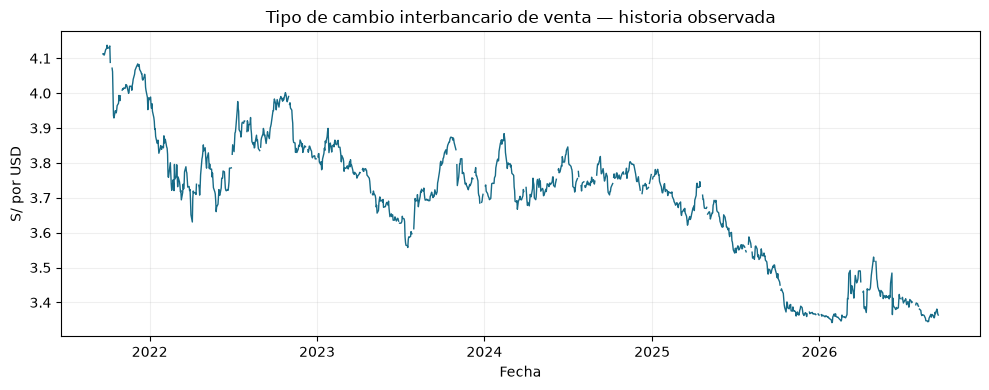

Retornos disponibles: 1240
Ventana base: 2025-09-09 a 2026-09-17


In [7]:
mercado["retorno_log"] = np.log(mercado["tc_venta"] / mercado["tc_venta"].shift(1))
retornos = mercado["retorno_log"].dropna()

vol_diaria = retornos.tail(VENTANA_BASE).std(ddof=1)
vol_anualizada = vol_diaria * np.sqrt(252)
tc_actual = mercado["tc_venta"].iloc[-1]

print(f"Última referencia interbancaria disponible: S/ {tc_actual:.4f} por US$")
print(f"Volatilidad diaria ({VENTANA_BASE} observaciones): {vol_diaria:.4%}")
print(f"Volatilidad anualizada referencial: {vol_anualizada:.2%}")


# Conservar huecos visibles: no unir mediante una recta periodos n.d.
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tc["fecha"], tc[col_venta], linewidth=1, color="#176b87")
ax.set(title="Tipo de cambio interbancario de venta — historia observada", xlabel="Fecha", ylabel="S/ por USD")
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()

if len(retornos) < 504:
    raise ValueError("Se necesitan al menos 504 retornos para ambas ventanas")
print("Retornos disponibles:", len(retornos))
print("Ventana base:", mercado.loc[retornos.tail(VENTANA_BASE).index, "fecha"].min().date(), "a", fecha_referencia.date())


### Interpretación de los resultados

La serie comienza en S/ 4.1127 y termina en S/ 3.3637, un cambio acumulado de -18.21%; el rango histórico es S/ 3.3420–4.1375. La volatilidad de los últimos 252 retornos es 0.4204%, anualizada a 6.67%. Un nivel alto en la gráfica no implica por sí solo alta volatilidad. Los retornos se calculan entre observaciones válidas consecutivas: si hay días sin dato pueden abarcar varios días; la etiqueta diaria y la anualización son aproximaciones académicas, no estimaciones corregidas por duración.

### Pausa guiada 2

¿Qué significa para una empresa importadora que aumente la volatilidad aunque el tipo de cambio promedio permanezca similar?

### Respuesta — Pausa guiada 2

Una mayor volatilidad representa más dispersión de cambios del tipo de cambio y puede ampliar los costos posibles aun con promedio similar. La empresa debe evaluar la cola de costos y su presupuesto, además del promedio. No se afirma que toda mayor volatilidad aumente necesariamente la probabilidad de sobrecosto: también influyen la media y la forma de la distribución.

## BLOQUE 3 — Simulación Monte Carlo

### Celda 8 — Bootstrap histórico de retornos

### Propósito y justificación

Esta celda toma la ventana reciente de retornos y genera escenarios mediante bootstrap con reemplazo. Convierte los 60 días calendario en días hábiles aproximados, acumula retornos simulados y obtiene una distribución del tipo de cambio final con semilla fija.

Horizonte hábil aproximado: 41


,tc_final_simulado
count,20000.000000
mean,3.341447
std,0.089860
min,2.867262
5%,3.189449
50%,3.343229
95%,3.485983
max,3.765520


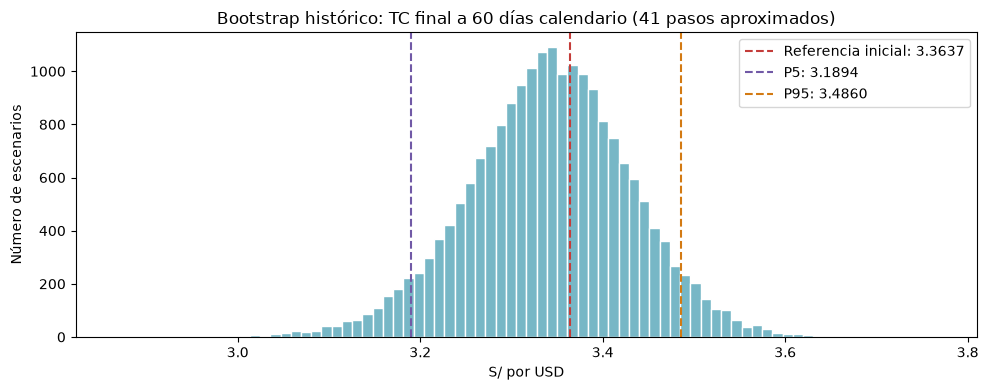

In [8]:
def dias_habiles_aproximados(dias_calendario):
    return max(1, round(dias_calendario * 252 / 365))

def simular_tc_final(retornos_historicos, tc_inicial, horizonte_calendario,
                     escenarios=20_000, semilla=2026):
    if horizonte_calendario <= 0 or tc_inicial <= 0 or escenarios < 1:
        raise ValueError("Horizonte, cotización y escenarios deben ser positivos")
    horizonte_habil = dias_habiles_aproximados(horizonte_calendario)
    muestra = np.asarray(retornos_historicos.dropna(), dtype=float)
    if not np.isfinite(muestra).all():
        raise ValueError("Retornos no finitos")
    if len(muestra) < 30:
        raise ValueError("No hay suficientes retornos históricos para simular.")
    rng = np.random.default_rng(semilla)
    caminos = rng.choice(muestra, size=(escenarios, horizonte_habil), replace=True)
    retornos_acumulados = caminos.sum(axis=1)
    tc_final = tc_inicial * np.exp(retornos_acumulados)
    return tc_final, horizonte_habil

retornos_base = retornos.tail(VENTANA_BASE)
tc_simulado, HORIZONTE_HABIL = simular_tc_final(
    retornos_base, tc_actual, HORIZONTE_CALENDARIO, ESCENARIOS, SEMILLA
)

resumen_tc = pd.Series(tc_simulado).describe(percentiles=[0.05, 0.50, 0.95])
print("Horizonte hábil aproximado:", HORIZONTE_HABIL)
display(resumen_tc.to_frame("tc_final_simulado"))


q05, q50, q95 = np.quantile(tc_simulado, [.05, .50, .95])
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(tc_simulado, bins=80, color="#77b7c6", edgecolor="white")
for value, label, color in [(tc_actual, "Referencia inicial", "#c43c39"), (q05, "P5", "#7159a6"), (q95, "P95", "#d37a13")]:
    ax.axvline(value, color=color, linestyle="--", label=f"{label}: {value:.4f}")
ax.set(title="Bootstrap histórico: TC final a 60 días calendario (41 pasos aproximados)", xlabel="S/ por USD", ylabel="Número de escenarios")
ax.legend()
fig.tight_layout()
plt.show()


### Interpretación de los resultados

El histograma concentra escenarios alrededor de una mediana de S/ 3.3432; el promedio es S/ 3.3414. El 90 % central queda aproximadamente entre P5 = 3.1894 y P95 = 3.4860. Las tres líneas identifican P5, P95 y referencia inicial. Aproximadamente 5 % de escenarios supera P95: este no es un máximo ni una garantía. El bootstrap preserva la distribución empírica y su media, pero al remuestrear independientemente pierde dependencia temporal y agrupación de volatilidad. Los 41 pasos son una aproximación de 60 días calendario sin calendario exacto de feriados.

### Pausa guiada 3

La distribución anterior no es un intervalo de confianza del tipo de cambio. Representa escenarios futuros simulados bajo el supuesto de que los retornos recientes son una referencia útil para el horizonte analizado.

## BLOQUE 4 — Comparación y motor de decisión

### Celda 9 — Comprar hoy frente a esperar

### Propósito y justificación

Esta celda traduce cada tipo de cambio simulado a soles para comparar dos alternativas homogéneas: comprar los USD hoy o esperar. Calcula costo esperado, probabilidad de sobrecosto y percentil 95, además de sus diferencias porcentuales frente al costo actual.

In [9]:
costo_comprar_hoy = MONTO_USD * tc_actual
costos_esperar = MONTO_USD * tc_simulado

costo_esperado = costos_esperar.mean()
prob_sobrecosto = np.mean(costos_esperar > costo_comprar_hoy)
p95_costo = np.percentile(costos_esperar, 95)
sobrecosto_esperado_pct = costo_esperado / costo_comprar_hoy - 1
sobrecosto_p95_pct = p95_costo / costo_comprar_hoy - 1

comparacion = pd.DataFrame({
    "indicador": [
        "Costo de comprar hoy", "Costo esperado si se espera",
        "Probabilidad de sobrecosto", "Percentil 95 del costo",
        "Sobrecosto esperado (%)", "Sobrecosto P95 (%)"
    ],
    "valor": [
        costo_comprar_hoy, costo_esperado, prob_sobrecosto,
        p95_costo, sobrecosto_esperado_pct, sobrecosto_p95_pct
    ]
})
comparacion["unidad"] = ["S/", "S/", "%", "S/", "%", "%"]
comparacion.loc[[2, 4, 5], "valor"] *= 100
display(comparacion.style.format({"valor": "{:,.4f}"}))

,indicador,valor,unidad
0,Costo de comprar hoy,"336,371.4286",S/
1,Costo esperado si se espera,"334,144.7278",S/
2,Probabilidad de sobrecosto,40.6400,%
3,Percentil 95 del costo,"348,598.3357",S/
4,Sobrecosto esperado (%),-0.6620,%
5,Sobrecosto P95 (%),3.6349,%


### Interpretación de los resultados

Comprar al precio de referencia cuesta S/ 336,371.43; esperar tiene costo medio simulado de S/ 334,144.73, una diferencia de S/ -2,226.70 (-0.6620%). Aun con menor promedio, 40.64% de escenarios cuesta más. La tabla expresa los porcentajes multiplicados por 100 y distingue unidades; no compara valores actuales a valor presente porque omite intereses y financiamiento.

### Celda 10 — Tabla de riesgo e interpretación

### Propósito y justificación

Esta celda reúne en una tabla las métricas principales de tipo de cambio, costo y probabilidad. El texto posterior traduce la simulación a una lectura empresarial sin confundir una probabilidad modelada con una certeza futura.

In [10]:
tabla_riesgo = pd.DataFrame({
    "Métrica": ["TC actual", "TC esperado", "TC P95", "Costo hoy", "Costo esperado", "Costo P95", "Prob. sobrecosto"],
    "Resultado": [tc_actual, tc_simulado.mean(), np.percentile(tc_simulado, 95),
                  costo_comprar_hoy, costo_esperado, p95_costo, prob_sobrecosto]
})
tabla_riesgo["Unidad"] = ["S/ por USD"]*3 + ["S/"]*3 + ["%"]
tabla_riesgo.loc[6, "Resultado"] *= 100
display(tabla_riesgo.style.format({"Resultado": "{:,.4f}"}))

print(
    f"Si la empresa espera, el modelo estima una probabilidad de {prob_sobrecosto:.1%} "
    f"de pagar más que si compra hoy. En el percentil 95, el costo alcanzaría "
    f"S/ {p95_costo:,.2f}."
)

,Métrica,Resultado,Unidad
0,TC actual,3.3637,S/ por USD
1,TC esperado,3.3414,S/ por USD
2,TC P95,3.4860,S/ por USD
3,Costo hoy,"336,371.4286",S/
4,Costo esperado,"334,144.7278",S/
5,Costo P95,"348,598.3357",S/
6,Prob. sobrecosto,40.6400,%


Si la empresa espera, el modelo estima una probabilidad de 40.6% de pagar más que si compra hoy. En el percentil 95, el costo alcanzaría S/ 348,598.34.


### Interpretación de los resultados

El P95 del costo es S/ 348,598.34, S/ 12,226.91 (3.6349%) sobre la referencia. La probabilidad 40.64% es condicional al modelo. Su error Monte Carlo aproximado es 0.35 puntos porcentuales (un error estándar); no mide incertidumbre del modelo ni del futuro.

### Celda 11 — Motor transparente de decisión

### Propósito y justificación

Esta celda implementa una regla transparente: recomienda comprar hoy si la probabilidad de sobrecosto o el sobrecosto P95 exceden sus tolerancias; de lo contrario recomienda esperar. Antes de decidir, valida que las métricas y tolerancias sean finitas y coherentes.

In [11]:
def motor_decision(prob_sobrecosto, sobrecosto_p95_pct,
                   tolerancia_prob=0.40, tolerancia_p95=0.02):
    métricas = [prob_sobrecosto, sobrecosto_p95_pct, tolerancia_prob, tolerancia_p95]
    if not all(np.isfinite(métricas)):
        raise ValueError("Las métricas y tolerancias deben ser valores numéricos finitos.")
    if not (0 <= tolerancia_prob <= 1 and tolerancia_p95 >= 0):
        raise ValueError("Las tolerancias deben ser no negativas y la probabilidad no puede exceder 100 %.")

    if not 0 <= prob_sobrecosto <= 1:
        raise ValueError("La probabilidad debe estar entre 0 y 1")
    razones = []
    if prob_sobrecosto > tolerancia_prob:
        razones.append(
            f"probabilidad de sobrecosto {prob_sobrecosto:.1%} > límite {tolerancia_prob:.1%}"
        )
    if sobrecosto_p95_pct > tolerancia_p95:
        razones.append(
            f"sobrecosto P95 {sobrecosto_p95_pct:.1%} > límite {tolerancia_p95:.1%}"
        )
    decision = "COMPRAR HOY" if razones else "ESPERAR"
    return decision, razones or ["los dos indicadores permanecen dentro de los umbrales definidos"]

decision_base, razones_base = motor_decision(
    prob_sobrecosto,
    sobrecosto_p95_pct,
    TOLERANCIA_PROB_SOBRECOSTO,
    TOLERANCIA_SOBRECOSTO_P95,
)

print("DECISIÓN DEL MOTOR:", decision_base)
print("Razones:")
for razon in razones_base:
    print("-", razon)

print("\nImportante: el motor aplica una política académica explícita; no reemplaza el juicio gerencial.")

DECISIÓN DEL MOTOR: COMPRAR HOY
Razones:
- probabilidad de sobrecosto 40.6% > límite 40.0%
- sobrecosto P95 3.6% > límite 2.0%

Importante: el motor aplica una política académica explícita; no reemplaza el juicio gerencial.


### Interpretación de los resultados

El motor recomienda **COMPRAR HOY**: probabilidad 40.64% frente al límite 40 %, y sobrecosto P95 3.6349% frente al 2 %. Basta exceder uno. El P95 sustenta la decisión aun cuando la probabilidad se encuentra cerca del umbral. Esta regla prioriza tolerancia de riesgo; no maximiza el ahorro medio.

## BLOQUE 5 — Sensibilidad y robustez

### Celda 12 — Comparación de ventanas históricas

### Propósito y justificación

Esta celda repite el análisis usando ventanas históricas de 252 y 504 observaciones. La comparación evalúa si la decisión es robusta frente a una elección razonable de historia reciente, manteniendo constantes el monto, el horizonte, la semilla y las tolerancias.

In [12]:
def evaluar_ventana(n):
    if len(retornos) < n:
        raise ValueError("Ventana incompleta")
    muestra = retornos.tail(n)
    simulados, _ = simular_tc_final(
        muestra, tc_actual, HORIZONTE_CALENDARIO, ESCENARIOS, SEMILLA
    )
    costos = MONTO_USD * simulados
    prob = np.mean(costos > costo_comprar_hoy)
    p95 = np.percentile(costos, 95)
    p95_pct = p95 / costo_comprar_hoy - 1
    decision, _ = motor_decision(
        prob, p95_pct,
        TOLERANCIA_PROB_SOBRECOSTO,
        TOLERANCIA_SOBRECOSTO_P95,
    )
    return {
        "ventana": n,
        "volatilidad_diaria": muestra.std(ddof=1),
        "costo_esperado": costos.mean(),
        "prob_sobrecosto": prob,
        "costo_p95": p95,
        "sobrecosto_p95_pct": p95_pct,
        "decision": decision,
    }

sensibilidad = pd.DataFrame([evaluar_ventana(252), evaluar_ventana(504)])
display(sensibilidad.style.format({"volatilidad_diaria": "{:.4%}", "costo_esperado": "S/ {:,.2f}", "prob_sobrecosto": "{:.2%}", "costo_p95": "S/ {:,.2f}", "sobrecosto_p95_pct": "{:.4%}"}))

if sensibilidad["decision"].nunique() > 1:
    print("La decisión cambia: el resultado es sensible a la ventana histórica.")
else:
    print("La decisión no cambia entre ventanas, pero siguen existiendo supuestos no modelados.")

,ventana,volatilidad_diaria,costo_esperado,prob_sobrecosto,costo_p95,sobrecosto_p95_pct,decision
0,252,0.4204%,"S/ 334,144.73",40.64%,"S/ 348,598.34",3.6349%,COMPRAR HOY
1,504,0.3642%,"S/ 333,383.52",34.59%,"S/ 345,997.26",2.8617%,COMPRAR HOY


La decisión no cambia entre ventanas, pero siguen existiendo supuestos no modelados.


### Interpretación de los resultados

Con 252 retornos: probabilidad 40.64%, sobrecosto P95 3.6349%. Con 504: 34.59% y 2.8617%. Ambas ventanas recomiendan comprar; en la de 504 la probabilidad queda por debajo del 40 %, pero el P95 sigue por encima del 2 %. La estabilidad se limita a estas dos ventanas y al mismo modelo.

## Reto de aplicación en clase

La gerencia reduce su tolerancia máxima de probabilidad de sobrecosto a **25 %**. Modifique únicamente ese umbral, vuelva a ejecutar el motor y compare la decisión con la original.

### Propósito y justificación

Esta celda modifica únicamente la tolerancia de probabilidad solicitada en el reto y vuelve a ejecutar el mismo motor. Mantener las demás entradas constantes permite atribuir el cambio de decisión al umbral y no a una simulación distinta.

In [13]:
TOLERANCIA_RETO = 0.25

decision_reto, razones_reto = motor_decision(
    prob_sobrecosto,
    sobrecosto_p95_pct,
    tolerancia_prob=TOLERANCIA_RETO,
    tolerancia_p95=TOLERANCIA_SOBRECOSTO_P95,
)

print("Decisión original:", decision_base)
print("Decisión con tolerancia de 25 %:", decision_reto)
print("Razones del nuevo resultado:")
for razon in razones_reto:
    print("-", razon)

Decisión original: COMPRAR HOY
Decisión con tolerancia de 25 %: COMPRAR HOY
Razones del nuevo resultado:
- probabilidad de sobrecosto 40.6% > límite 25.0%
- sobrecosto P95 3.6% > límite 2.0%


### Interpretación de los resultados

Al reducir la tolerancia a 25 %, la decisión permanece **COMPRAR HOY**: 40.64% supera 25 % y el P95 excede 2 %. No cambian los escenarios ni su distribución. Endurecer este umbral nunca puede convertir COMPRAR HOY en ESPERAR, manteniendo las demás entradas.

## Síntesis ejecutiva guiada

Redacte durante la clase una síntesis breve que incluya:

- **Evidencia:** TC actual, costo hoy, costo esperado, probabilidad de sobrecosto y P95.
- **Inferencia:** qué revela la distribución simulada.
- **Decisión:** comprar hoy o esperar y por qué.
- **Condición de cambio:** qué umbral o supuesto haría cambiar la decisión.
- **Limitación:** al menos dos elementos no modelados, como spread, costo de financiamiento o instrumentos de cobertura.

### Preparación de la síntesis

Esta celda arma la síntesis ejecutiva a partir de las variables calculadas: evidencia, inferencia, decisión, condición de cambio y limitaciones. Al generarse después del análisis, evita copiar manualmente cifras que podrían quedar desactualizadas al cambiar la fecha o los datos.

In [14]:
from IPython.display import Markdown

razón_principal = "; ".join(razones_base)
síntesis = f"""
### Síntesis ejecutiva del caso

- **Evidencia.** El TC de venta observado es **S/ {tc_actual:.4f} por USD**. Comprar hoy costaría **S/ {costo_comprar_hoy:,.2f}**. Si se espera, el costo medio simulado es **S/ {costo_esperado:,.2f}**, la probabilidad de pagar más que hoy es **{prob_sobrecosto:.1%}** y el costo P95 es **S/ {p95_costo:,.2f}**.
- **Inferencia.** La simulación muestra escenarios favorables y adversos bajo el supuesto de que los retornos históricos son una referencia útil. No es un pronóstico garantizado ni un intervalo de confianza.
- **Decisión.** Con la política definida, el motor recomienda **{decision_base}** porque {razón_principal}. No implica que el tipo de cambio futuro sea conocido.
- **Condición de cambio.** Con los demás supuestos intactos, el motor podría recomendar esperar si sus tolerancias fueran al menos **{prob_sobrecosto:.4%}** para la probabilidad de sobrecosto y **{sobrecosto_p95_pct:.6%}** para el sobrecosto P95, o si otra muestra redujera ambas métricas bajo los límites actuales.
- **Limitaciones.** No se incorporan spread bancario efectivo, comisiones, costo de financiamiento, feriados exactos, cambios estructurales ni instrumentos de cobertura como forwards u opciones. Sirve para transparentar el riesgo, no para reemplazar una cotización o política de tesorería.
"""
display(Markdown(síntesis))
# Prueba de una política alternativa concreta, con margen sobre ambos límites.
tolerancia_alternativa_prob = np.ceil(prob_sobrecosto*10000)/10000
tolerancia_alternativa_p95 = np.ceil(max(0, sobrecosto_p95_pct)*10000)/10000
decision_alternativa, _ = motor_decision(prob_sobrecosto, sobrecosto_p95_pct, tolerancia_alternativa_prob, tolerancia_alternativa_p95)
print(f"Política alternativa comprobada: {tolerancia_alternativa_prob:.2%}, {tolerancia_alternativa_p95:.2%} -> {decision_alternativa}")



### Síntesis ejecutiva del caso

- **Evidencia.** El TC de venta observado es **S/ 3.3637 por USD**. Comprar hoy costaría **S/ 336,371.43**. Si se espera, el costo medio simulado es **S/ 334,144.73**, la probabilidad de pagar más que hoy es **40.6%** y el costo P95 es **S/ 348,598.34**.
- **Inferencia.** La simulación muestra escenarios favorables y adversos bajo el supuesto de que los retornos históricos son una referencia útil. No es un pronóstico garantizado ni un intervalo de confianza.
- **Decisión.** Con la política definida, el motor recomienda **COMPRAR HOY** porque probabilidad de sobrecosto 40.6% > límite 40.0%; sobrecosto P95 3.6% > límite 2.0%. No implica que el tipo de cambio futuro sea conocido.
- **Condición de cambio.** Con los demás supuestos intactos, el motor podría recomendar esperar si sus tolerancias fueran al menos **40.6400%** para la probabilidad de sobrecosto y **3.634942%** para el sobrecosto P95, o si otra muestra redujera ambas métricas bajo los límites actuales.
- **Limitaciones.** No se incorporan spread bancario efectivo, comisiones, costo de financiamiento, feriados exactos, cambios estructurales ni instrumentos de cobertura como forwards u opciones. Sirve para transparentar el riesgo, no para reemplazar una cotización o política de tesorería.


Política alternativa comprobada: 40.64%, 3.64% -> ESPERAR


### Interpretación de la condición de cambio

La condición para esperar requiere que ambos indicadores queden dentro de sus límites. Se verificó una alternativa concreta de 40.64% y 3.64%, que produce ESPERAR. Usar 40.6% y 3.63% redondeados hacia abajo podía seguir activando COMPRAR HOY: por eso los umbrales deben compararse con precisión completa.

## Ticket de salida

En una frase, responda la pregunta orientadora e indique una evidencia concreta producida por el notebook.



### Preparación de la respuesta

Esta celda produce una respuesta de una frase para el ticket de salida, conectando la pregunta orientadora con una evidencia concreta del notebook. Usa la probabilidad simulada, el P95 y el costo de comprar hoy que se calcularon arriba.

In [15]:
ticket_salida = (
    f"Una decisión defendible frente al riesgo cambiario compara comprar hoy con una distribución de escenarios "
    f"y aplica una tolerancia explícita, en lugar de asumir un único tipo de cambio futuro; en esta ejecución, "
    f"la evidencia fue una probabilidad de sobrecosto de {prob_sobrecosto:.1%} y un costo P95 de "
    f"S/ {p95_costo:,.2f} frente a S/ {costo_comprar_hoy:,.2f} si se compra hoy."
)
display(Markdown(f"### Respuesta\n{ticket_salida}"))

### Respuesta
Una decisión defendible frente al riesgo cambiario compara comprar hoy con una distribución de escenarios y aplica una tolerancia explícita, en lugar de asumir un único tipo de cambio futuro; en esta ejecución, la evidencia fue una probabilidad de sobrecosto de 40.6% y un costo P95 de S/ 348,598.34 frente a S/ 336,371.43 si se compra hoy.